# EDA 04 (Previous Application)

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sys.path.insert(0, str(Path.cwd().parent))
from src.data.loader import load_table, verify_dtypes
from src.features.eval import EvaluadorSenal

COLOR_NODEF, COLOR_DEF = "steelblue", "crimson"

### 1. Carga

In [2]:
prev = load_table("previous_application")
train = load_table("application_train").copy()  # copia: el ajuste de tipos deja el frame fragmentado

prev.info(memory_usage="deep")
prev.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   SK_ID_PREV                   1670214 non-null  uint32  
 1   SK_ID_CURR                   1670214 non-null  uint32  
 2   NAME_CONTRACT_TYPE           1670214 non-null  category
 3   AMT_ANNUITY                  1297979 non-null  float32 
 4   AMT_APPLICATION              1670214 non-null  float32 
 5   AMT_CREDIT                   1670213 non-null  float32 
 6   AMT_DOWN_PAYMENT             774370 non-null   float32 
 7   AMT_GOODS_PRICE              1284699 non-null  float32 
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  category
 9   HOUR_APPR_PROCESS_START      1670214 non-null  uint8   
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  category
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  uint8   
 12  RATE_DOWN_PAYMENT           

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430054,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615234,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735352,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335938,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.394531,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# cada fila es una solicitud previa: la clave es SK_ID_PREV, SK_ID_CURR se repite por cliente
assert prev["SK_ID_PREV"].is_unique, "SK_ID_PREV no es identificador único"
print(f"solicitudes: {len(prev):,} | clientes distintos: {prev['SK_ID_CURR'].nunique():,}")
print(f"Integridad: SK_ID_PREV único | duplicados de fila completa: {int(prev.duplicated().sum())}")
print(f"nulos en las claves: {prev[['SK_ID_PREV', 'SK_ID_CURR']].isnull().sum().to_dict()}")

solicitudes: 1,670,214 | clientes distintos: 338,857


Integridad: SK_ID_PREV único | duplicados de fila completa: 0
nulos en las claves: {'SK_ID_PREV': 0, 'SK_ID_CURR': 0}


In [4]:
# la cobertura es directa por SK_ID_CURR: no hay tabla puente ni créditos huérfanos posibles
tiene_prev = train["SK_ID_CURR"].isin(prev["SK_ID_CURR"])
print(f"clientes de train con solicitudes previas: {tiene_prev.sum():,} ({tiene_prev.mean() * 100:.2f}%)")
print(f"clientes de train sin ninguna: {(~tiene_prev).sum():,}")
print(f"solicitudes enlazables a train: {prev['SK_ID_CURR'].isin(train['SK_ID_CURR']).sum():,}")

# en el buró el grupo sin historial era el de más riesgo, aquí espero lo contrario
ev_cli = EvaluadorSenal(train, train["TARGET"])
ev_cli.evaluar_flags([("HAS_PREV_APPLICATION", tiene_prev.astype(int).values, None, "global")])

clientes de train con solicitudes previas: 291,057 (94.65%)
clientes de train sin ninguna: 16,454
solicitudes enlazables a train: 1,413,701


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
HAS_PREV_APPLICATION,global,8.19% (n=291057),5.96% (n=16454),+2.24 pp,10.2,1.2383986890374153e-24


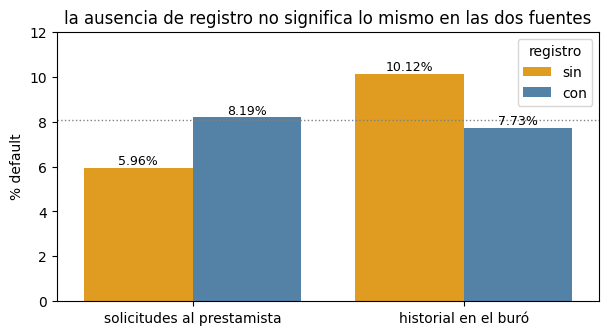

In [5]:
# no tener registro, ¿protege o penaliza? la misma pregunta en las dos fuentes de historial
bureau_ids = load_table("bureau", usecols=["SK_ID_CURR"], reduce_memory=False)["SK_ID_CURR"]
tiene_bureau = train["SK_ID_CURR"].isin(bureau_ids)

comp = pd.DataFrame([
    {"fuente": "solicitudes al prestamista", "registro": "sin", "tasa": train["TARGET"][~tiene_prev].mean()},
    {"fuente": "solicitudes al prestamista", "registro": "con", "tasa": train["TARGET"][tiene_prev].mean()},
    {"fuente": "historial en el buró", "registro": "sin", "tasa": train["TARGET"][~tiene_bureau].mean()},
    {"fuente": "historial en el buró", "registro": "con", "tasa": train["TARGET"][tiene_bureau].mean()},
])
comp["tasa"] *= 100

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(comp, x="fuente", y="tasa", hue="registro",
            palette={"sin": "orange", "con": COLOR_NODEF}, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f%%", fontsize=9)
ax.axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1)
ax.set(xlabel="", ylabel="% default", ylim=(0, 12),
       title="la ausencia de registro no significa lo mismo en las dos fuentes")
plt.show()

In [6]:
# ¿veo todas las solicitudes de cada cliente o solo un tramo? la más antigua lo delata: si en ella
# el cliente ya constaba como recurrente, hubo solicitudes anteriores que no están en la tabla
prev_t = prev[prev["SK_ID_CURR"].isin(train["SK_ID_CURR"])]
primera = prev_t.loc[prev_t.groupby("SK_ID_CURR")["DAYS_DECISION"].idxmin()].copy()
primera["TARGET"] = primera["SK_ID_CURR"].map(train.set_index("SK_ID_CURR")["TARGET"])

t = primera.groupby("NAME_CLIENT_TYPE", observed=True).agg(
    clientes=("SK_ID_CURR", "size"), dias_mediana=("DAYS_DECISION", "median"), tasa=("TARGET", "mean"))
t["% de clientes"] = (t["clientes"] / len(primera) * 100).round(2)
t["% default"] = (t.pop("tasa") * 100).round(2)
# ¿se apilan contra el corte de la ventana o se reparten como los nuevos?
t["% antes de -2.500 días"] = (primera.assign(p=primera["DAYS_DECISION"] < -2500)
                               .groupby("NAME_CLIENT_TYPE", observed=True)["p"].mean() * 100).round(2)
display(t)

print(f"ventana de la tabla: {prev['DAYS_DECISION'].min()} días ({-prev['DAYS_DECISION'].min() / 365.25:.1f} años)")
dup_contrato = prev["FLAG_LAST_APPL_PER_CONTRACT"].eq("N")
dup_dia = prev["NFLAG_LAST_APPL_IN_DAY"].eq(0)
print(f"registros que no son el último de su contrato: {dup_contrato.sum():,} ({dup_contrato.mean() * 100:.2f}%) | "
      f"que no son el último del día: {dup_dia.sum():,} ({dup_dia.mean() * 100:.2f}%)")

,clientes,dias_mediana,% de clientes,% default,% antes de -2.500 días
NAME_CLIENT_TYPE,,,,,
New,237097,-1320.0,81.46,8.76,14.17
Refreshed,18509,-1348.0,6.36,5.66,5.24
Repeater,35425,-2662.0,12.17,5.71,69.36
XNA,26,-172.0,0.01,3.85,0.00


ventana de la tabla: -2922 días (8.0 años)
registros que no son el último de su contrato: 8,475 (0.51%) | que no son el último del día: 5,900 (0.35%)


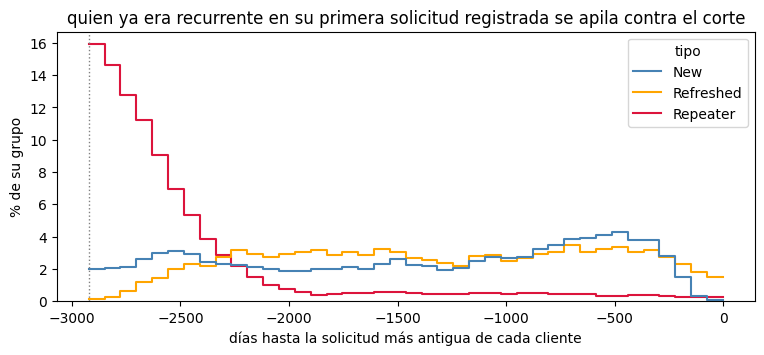

In [7]:
# si el recorte fuese aleatorio, los recurrentes se repartirían como los nuevos: se amontonan en el corte
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(data=primera.assign(tipo=primera["NAME_CLIENT_TYPE"].astype(str)).query("tipo != 'XNA'"),
             x="DAYS_DECISION", hue="tipo", bins=40, stat="percent", common_norm=False,
             element="step", fill=False,
             palette={"New": COLOR_NODEF, "Repeater": COLOR_DEF, "Refreshed": "orange"}, ax=ax)
ax.axvline(prev["DAYS_DECISION"].min(), color="gray", ls=":", lw=1)
ax.set(xlabel="días hasta la solicitud más antigua de cada cliente", ylabel="% de su grupo",
       title="quien ya era recurrente en su primera solicitud registrada se apila contra el corte")
plt.show()

`previous_application` reúne 1.670.214 solicitudes previas al propio prestamista en 37 columnas y
ocupa 146,6 MB con los tipos ya ajustados. `SK_ID_PREV` es identificador único, no hay un solo
duplicado de fila ni un nulo en las claves, así que cada fila es una solicitud distinta. El enlace
con el cliente es directo por `SK_ID_CURR`, sin tabla puente ni registros huérfanos posibles, a
diferencia del histórico mensual del buró, que tenía que apoyarse en `bureau` para saber de quién
era cada crédito.

La cobertura es la más alta de las tablas del buró y de las previas: 291.057 clientes de los 307.511
(94,65%) tienen al menos una solicitud, y solo 16.454 no tienen ninguna. Lo que no esperaba es el
signo. En el buró, no tener historial era el grupo de más riesgo, con 10,12% de default frente al
7,73% de quien sí lo tenía. Aquí ocurre justo lo contrario: quien nunca ha solicitado nada al
prestamista da 5,96%, frente al 8,19% de quien sí lo ha hecho, una diferencia de 2,24pp que penaliza
a quien tiene solicitudes previas (z = 10,2, p = 1,24e-24). Las dos ausencias no significan lo mismo.
La del buró es opacidad, un cliente del que no hay rastro externo; esta es sencillamente un cliente
que llega nuevo al prestamista, y quien ya ha pasado por él lo ha hecho porque necesitaba
financiación. Al agregar por cliente esto tiene una consecuencia que conviene anticipar: rellenar
con cero a los que no aparecen mete un grupo de menor riesgo en el grupo 0 de cada variable, así que
la distorsión irá en dirección contraria a la que vi en el buró, inflando lo que penaliza y
enmascarando lo que protege. Lo mediré global y condicionado en lugar de darlo por bueno.

Antes de seguir quería saber si veo el historial completo de cada cliente o solo un tramo, porque de
eso depende que un cliente sin rechazos lo esté de verdad o solo en la parte que observo. La
solicitud más antigua de cada uno lo delata: si en ella ya constaba como recurrente, hubo otras
anteriores que no están recogidas. Pasa en el 18,53% de los clientes, un 12,17% que ya eran
recurrentes y un 6,36% que venían de refrescar una relación anterior.

No es aleatorio, aunque los dos grupos llegan ahí por caminos distintos y conviene no mezclarlos. El
registro se corta en 8,0 años exactos, porque `DAYS_DECISION` no baja de -2.922, y quien ya era
recurrente se apila contra ese corte: el 69,36% tiene su solicitud más antigua antes de los -2.500
días, con mediana en -2.662 frente a los -1.320 de quienes arrancan como nuevos. Es relación continua
que empezó antes de lo que puedo ver. Quien vuelve tras refrescar la relación no se apila en el
borde, solo el 5,24%, menos incluso que el 14,17% de los propios clientes nuevos, y su mediana está
en -1.348: son clientes que regresan tras un paréntesis largo, de modo que su actividad anterior
también queda fuera pero su primera solicitud visible puede caer en cualquier punto del periodo. En
los dos casos hay historial que no veo, y en los dos el riesgo es menor, 5,71% y 5,66% frente al
8,76% de los nuevos, así que lo que señala es antigüedad de relación y no ocultación.

La consecuencia es acotada pero real. Los conteos absolutos, cuántas solicitudes o cuántos rechazos
acumula un cliente, quedan recortados por abajo justo en los de relación más larga, mientras que las
proporciones y las recencias no sufren ese recorte. Prefiero por tanto los ratios y la recencia antes
que los conteos crudos, y me llevo como control la marca de tener relación anterior a lo que veo,
igual que hice con la ventana de observación del histórico mensual del buró.

Queda una salvedad menor sobre qué representa una fila. El 0,51% de los registros no es el último de
su contrato y el 0,35% no es el último de su día, o sea que una misma operación puede aparecer
repetida por reintento o modificación. No rompe la clave, pero implica que contar filas es contar
registros y no contratos distintos. Dejo pendiente para el diseño de la agregación si me quedo solo
con el último registro de cada contrato.

### 2. Distribución variable marco (solicitudes por cliente) + cruce con `TARGET`

count    307511.00
mean          4.60
std           4.18
min           0.00
25%           2.00
50%           3.00
75%           6.00
90%          10.00
95%          13.00
99%          20.00
max          73.00


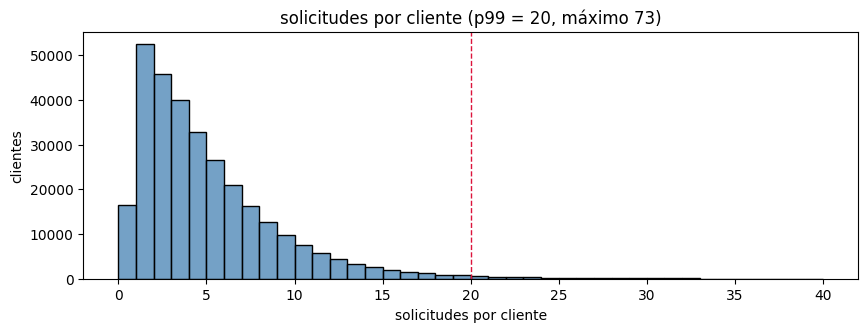

In [8]:
# solicitudes por cliente, contando también a los que no tienen ninguna
train["PREV_APPLICATION_COUNT"] = (prev_t.groupby("SK_ID_CURR").size()
                                   .reindex(train["SK_ID_CURR"], fill_value=0).values)
n_prev = train["PREV_APPLICATION_COUNT"]
print(n_prev.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 3.2))
sns.histplot(n_prev, bins=range(0, 41), color=COLOR_NODEF, ax=ax)
ax.axvline(n_prev.quantile(0.99), color=COLOR_DEF, ls="--", lw=1)
ax.set(xlabel="solicitudes por cliente", ylabel="clientes",
       title=f"solicitudes por cliente (p99 = {n_prev.quantile(0.99):.0f}, máximo {n_prev.max()})")
plt.show()

In [9]:
# ¿más solicitudes es más riesgo?
BINS, ETIQ = [-1, 0, 2, 5, 10, 100], ["0", "1 a 2", "3 a 5", "6 a 10", "11 o más"]
bins_prev = pd.cut(n_prev, BINS, labels=ETIQ)

t = train.groupby(bins_prev, observed=True)["TARGET"].agg(clientes="size", tasa="mean")
t["% de clientes"] = (t["clientes"] / len(train) * 100).round(2)
t["% default"] = (t.pop("tasa") * 100).round(2)
display(t)

con = tiene_prev.values
print(f"solo con previas: Pearson {pearsonr(n_prev[con], train['TARGET'][con])[0]:.4f} | "
      f"Spearman {spearmanr(n_prev[con], train['TARGET'][con])[0]:.4f}")

# el grupo 0 es de menor riesgo, así que la medida global arrastra hacia abajo el tramo bajo
ev_cli.evaluar_continuas([("PREV_APPLICATION_COUNT", True, None, "global (relleno 0)")])

,clientes,% de clientes,% default
PREV_APPLICATION_COUNT,,,
0,16454,5.35,5.96
1 a 2,98332,31.98,8.13
3 a 5,99574,32.38,7.75
6 a 10,67646,22.00,8.28
11 o más,25505,8.29,9.93


solo con previas: Pearson 0.0198 | Spearman 0.0101


Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_APPLICATION_COUNT,global (relleno 0),307511,0.0343,1.517476601597145e-19,3.0,4.0


In [10]:
# ¿el conteo mide intensidad de relación o antigüedad? los de historial recortado lo separan
recortado = (primera.set_index("SK_ID_CURR")["NAME_CLIENT_TYPE"].isin(["Repeater", "Refreshed"])
             .reindex(train["SK_ID_CURR"], fill_value=False).values)

t = (train.assign(bin=bins_prev.values, historial=pd.Series(recortado)
                  .map({False: "completo", True: "recortado"}).values)[con]
     .groupby(["historial", "bin"], observed=True)["TARGET"].agg(clientes="size", tasa="mean")
     .reset_index())
t["% default"] = (t.pop("tasa") * 100).round(2)
display(t.pivot(index="bin", columns="historial"))

# la medición válida va la última: el acumulador se queda con ella para el ranking
ev_cli.evaluar_continuas([
    ("PREV_APPLICATION_COUNT", False, con & ~recortado, "historial completo"),
    ("PREV_APPLICATION_COUNT", False, con & recortado, "historial recortado"),
    ("PREV_APPLICATION_COUNT", False, con, "con previas")])

clientes           % default          
historial completo recortado  completo recortado
bin                                             
1 a 2        85355     12977      8.60      5.10
3 a 5        80914     18660      8.30      5.37
6 a 10       52031     15615      8.98      5.92
11 o más     18823      6682     10.89      7.23

Variable,Población,n,Rank-Biserial,p-valor,Mediana (0),Mediana (1)
PREV_APPLICATION_COUNT,historial completo,237123,0.0271,7.17471583606348e-11,3.0,4.0
PREV_APPLICATION_COUNT,historial recortado,53934,0.063,3.6940755480901036e-09,5.0,5.0
PREV_APPLICATION_COUNT,con previas,291057,0.021,5.7987245591027506e-08,4.0,4.0


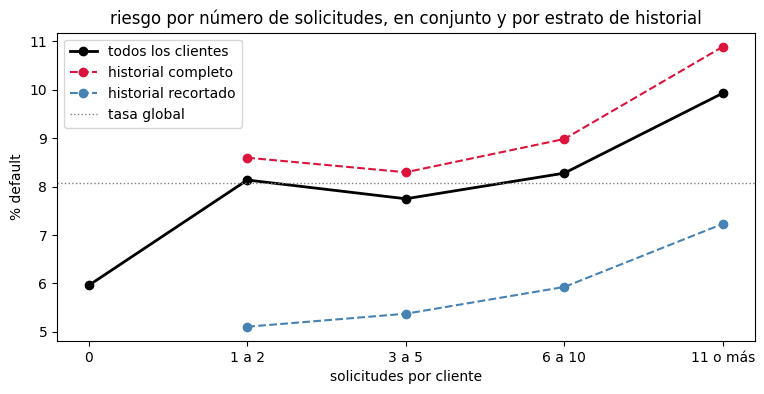

In [11]:
# las tres lecturas en un vistazo: la U, el salto de nivel entre estratos y dónde cae el grupo sin previas
tasa_bin = train.groupby(bins_prev, observed=True)["TARGET"].mean() * 100
tasa_estr = (train.assign(bin=bins_prev.values, historial=recortado)[con]
             .groupby(["historial", "bin"], observed=True)["TARGET"].mean() * 100)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ETIQ, tasa_bin.reindex(ETIQ), "o-", color="black", lw=2, label="todos los clientes")
ax.plot(ETIQ[1:], tasa_estr.xs(False).reindex(ETIQ[1:]), "o--", color=COLOR_DEF,
        label="historial completo")
ax.plot(ETIQ[1:], tasa_estr.xs(True).reindex(ETIQ[1:]), "o--", color=COLOR_NODEF,
        label="historial recortado")
ax.axhline(train["TARGET"].mean() * 100, color="gray", ls=":", lw=1, label="tasa global")
ax.set(xlabel="solicitudes por cliente", ylabel="% default",
       title="riesgo por número de solicitudes, en conjunto y por estrato de historial")
ax.legend()
plt.show()

In [12]:
# contar filas no es contar contratos: ¿cambia algo quedarse solo con el último registro de cada uno?
n_contr = (prev_t[prev_t["FLAG_LAST_APPL_PER_CONTRACT"].eq("Y")].groupby("SK_ID_CURR").size()
           .reindex(train["SK_ID_CURR"]).fillna(0).astype(int).values)

comp = pd.DataFrame({
    "clientes": train.groupby(bins_prev, observed=True).size(),
    "% default (registros)": train.groupby(bins_prev, observed=True)["TARGET"].mean() * 100,
    "% default (contratos)": (train.groupby(pd.cut(n_contr, BINS, labels=ETIQ), observed=True)["TARGET"]
                              .mean() * 100),
}).round(2)
display(comp)
print(f"clientes cuyo conteo cambia: {(n_prev.values != n_contr).sum():,} "
      f"({(n_prev.values != n_contr).mean() * 100:.2f}%) | "
      f"Pearson entre las dos versiones: {pearsonr(n_prev, n_contr)[0]:.4f}")

,clientes,% default (registros),% default (contratos)
0,16454,5.96,5.96
1 a 2,98332,8.13,8.14
3 a 5,99574,7.75,7.75
6 a 10,67646,8.28,8.27
11 o más,25505,9.93,9.94


clientes cuyo conteo cambia: 5,022 (1.63%) | Pearson entre las dos versiones: 0.9985


Lo primero que quiero saber de una tabla con varias filas por cliente es cuántas acumula cada uno. La
distribución es asimétrica y con cola larga: media de 4,60 solicitudes, mediana de 3, percentil 75 en
6, percentil 99 en 20 y un máximo de 73, del mismo orden que el máximo de 116 créditos que ya vi en
el historial del buró. La cola queda anotada para revisarla con el resto de valores extremos.

Esperaba un gradiente monótono creciente, del tipo cuantas más veces has pedido financiación peor te
comportas, y no es lo que sale. Reaparece la misma U que ya encontré con los créditos del buró: el
riesgo baja de 8,13% con una o dos solicitudes a 7,75% con tres a cinco, que es el mínimo, y desde
ahí sube a 8,28% y a 9,93% con once o más. Ni "más operaciones es más experiencia" ni "más
operaciones es sobreendeudamiento" gana de forma limpia, conviven las dos fuerzas. La diferencia con
el buró está en el extremo: allí el repunte final se quedaba en 8,18% y aquí llega a 9,93% sobre el
8,29% de los clientes, bastante más marcado.

La distorsión que temía al meter en el grupo bajo a quien no tiene ninguna solicitud aparece, y con
el signo contrario al que estoy acostumbrado. Midiendo sobre todos los clientes el conteo rinde
0,0343 y condicionado a tener alguna solicitud baja a 0,0210, o sea que se infla en lugar de
enmascararse. El mecanismo es el de siempre pero espejado, porque el grupo sin solicitudes es de
menor riesgo, 5,96%, y se sienta en el extremo bajo de una variable que penaliza, así que estira el
gradiente por abajo y regala pendiente. La cifra que vale es la condicionada.

Quería descartar que el conteo fuese antigüedad de relación disfrazada de volumen, y no lo es. El
gradiente se sostiene dentro de los dos grupos, de 8,60% a 10,89% en quienes tienen el historial
completo y de 5,10% a 7,23% en quienes ya tenían relación anterior a lo que veo, así que la
señal es propia. Lo llamativo es que en los recortados el efecto es más del doble, 0,0630 frente a
0,0271, y aun así el conjunto rinde menos que cualquiera de sus dos partes, 0,0210. La explicación
es que los recortados acumulan más solicitudes y a la vez tienen menos riesgo, de modo que
mezclarlos aplana la asociación. La medición honesta es la estratificada, y el recorte del historial
viaja como control y no como predictor.

Separar los dos grupos deja ver además que la U no es de los dos. En historial completo sí hay
bajada, de 8,60% a 8,30%, antes de subir a 8,98% y 10,89%, mientras que en historial recortado el
riesgo crece de principio a fin, 5,10%, 5,37%, 5,92% y 7,23%. O sea que la forma en U la pone el
cliente de relación corta, y entre los de relación larga más solicitudes es siempre peor, sin tramo
protector intermedio.

Sobre cómo codificarlo, la señal vive en el extremo y no en el orden. Pearson supera a Spearman,
0,0198 frente a 0,0101, justo lo contrario de lo que veía en las variables temporales del buró, donde
la brecha en sentido inverso delataba una relación monótona no lineal. Aquí ordenar a los clientes
por número de solicitudes aporta poco y lo que aporta es la cola, así que la codificación natural es
una flag de cola antes que el valor continuo o un binning fino. Con un efecto de 0,0210 el conteo por
sí solo es débil, en la misma línea del conteo de créditos del buró, y lo espero más como denominador
de las proporciones que construya que como variable por derecho propio.

Queda cerrada la duda de si una fila es una operación. Quedándome solo con el último registro de cada
contrato cambia el conteo de 5.022 clientes (1,63%), las dos versiones correlacionan 0,9985 y el
gradiente no se mueve ni una décima. Cuento filas sin filtrar, con la salvedad ya dicha de que una
misma operación puede aparecer repetida por reintento.

### 3. Verificación dtypes / Clasificación variables

In [13]:
chequeo = verify_dtypes("previous_application", prev)
print(chequeo["Estado"].value_counts().to_dict())
display(chequeo[chequeo["Estado"] != "OK"].style.hide(axis="index"))

{'OK': 34, 'IMPROVEMENT': 2, 'WARNING': 1}


Variable,Tipo Actual,Categoría Esperada,Estado,Detalle
FLAG_LAST_APPL_PER_CONTRACT,category,Binary/Flag,IMPROVEMENT,"Texto Y/N (['Y', 'N']). Convertir a boolean."
NFLAG_LAST_APPL_IN_DAY,uint8,Binary/Flag,IMPROVEMENT,Flag numérico (uint8). Representar como boolean o int8 para ahorrar memoria.
NAME_YIELD_GROUP,category,Binary/Flag,WARNING,"Flag no estándar: ['middle', 'low_action', 'high', 'low_normal', 'XNA']"


In [14]:
# el chequeo va por nombre y descripción, así que reviso los valores de las que dio por numéricas
for col in ["NFLAG_INSURED_ON_APPROVAL", "SELLERPLACE_AREA", "HOUR_APPR_PROCESS_START", "CNT_PAYMENT"]:
    print(f"{col:26s} {str(prev[col].dtype):8s} valores distintos: {prev[col].nunique():>5} | "
          f"mín {prev[col].min():>8.0f} | máx {prev[col].max():>8.0f} | "
          f"nulos {prev[col].isna().mean() * 100:5.2f}%")

valores = sorted(int(v) for v in prev["NFLAG_INSURED_ON_APPROVAL"].dropna().unique())
print(f"\nNFLAG_INSURED_ON_APPROVAL solo toma {valores}: es bandera, y es decimal por sus nulos")
zona = prev["SELLERPLACE_AREA"]
print(f"SELLERPLACE_AREA vale -1 en {zona.eq(-1).mean() * 100:.2f}% de las filas, llega a "
      f"{zona.max():,} y su segundo valor más frecuente es {zona.value_counts().index[1]}: "
      "es un código de zona, no una magnitud")

NFLAG_INSURED_ON_APPROVAL  float32  valores distintos:     2 | mín        0 | máx        1 | nulos 40.30%
SELLERPLACE_AREA           int32    valores distintos:  2097 | mín       -1 | máx  4000000 | nulos  0.00%
HOUR_APPR_PROCESS_START    uint8    valores distintos:    24 | mín        0 | máx       23 | nulos  0.00%


CNT_PAYMENT                float32  valores distintos:    49 | mín        0 | máx       84 | nulos 22.29%

NFLAG_INSURED_ON_APPROVAL solo toma [0, 1]: es bandera, y es decimal por sus nulos
SELLERPLACE_AREA vale -1 en 45.66% de las filas, llega a 4,000,000 y su segundo valor más frecuente es 0: es un código de zona, no una magnitud


In [15]:
# partición explícita: es la que decide qué columnas entran en cada análisis posterior, así que
# el conteo, el código de zona y la hora van separados aunque los tres sean enteros
GRUPOS = {
    "identificador": ["SK_ID_PREV", "SK_ID_CURR"],
    "bandera": ["FLAG_LAST_APPL_PER_CONTRACT", "NFLAG_LAST_APPL_IN_DAY", "NFLAG_INSURED_ON_APPROVAL"],
    "temporal": ["DAYS_DECISION", "DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION",
                 "DAYS_LAST_DUE", "DAYS_TERMINATION"],
    "importe": ["AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT", "AMT_DOWN_PAYMENT", "AMT_GOODS_PRICE"],
    "tasa": ["RATE_DOWN_PAYMENT", "RATE_INTEREST_PRIMARY", "RATE_INTEREST_PRIVILEGED"],
    "conteo": ["CNT_PAYMENT"],
    "código": ["SELLERPLACE_AREA"],
    "cíclica": ["HOUR_APPR_PROCESS_START"],
}
asignadas = [c for cols in GRUPOS.values() for c in cols]
GRUPOS["categórica"] = [c for c in prev.columns if c not in asignadas]

asignadas = [c for cols in GRUPOS.values() for c in cols]
assert len(asignadas) == len(set(asignadas)), "hay columnas en más de un grupo"
assert set(asignadas) == set(prev.columns), "la partición no cubre todas las columnas"
print({g: len(cols) for g, cols in GRUPOS.items()}, f"| total {len(asignadas)}")

{'identificador': 2, 'bandera': 3, 'temporal': 6, 'importe': 5, 'tasa': 3, 'conteo': 1, 'código': 1, 'cíclica': 1, 'categórica': 15} | total 37


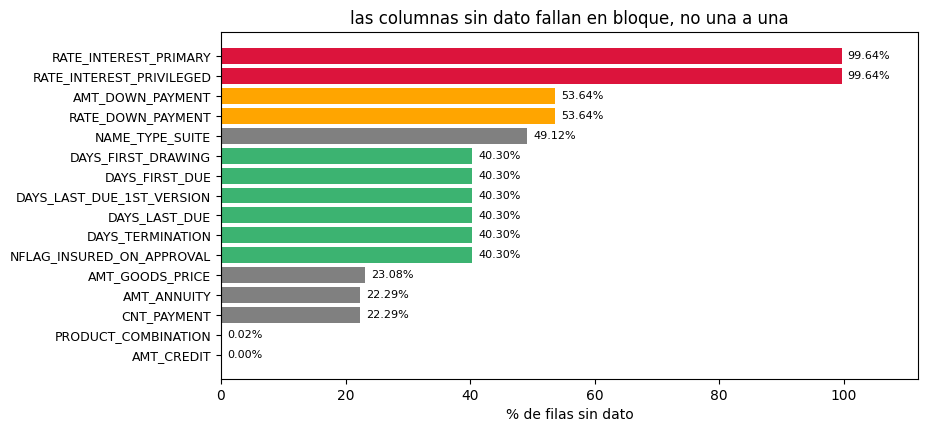

columnas con algún dato ausente: 16 de 37
  bloque de 2 columnas, 1,664,263 filas sin dato (99.64%): RATE_INTEREST_PRIMARY, RATE_INTEREST_PRIVILEGED
  bloque de 2 columnas, 895,844 filas sin dato (53.64%): AMT_DOWN_PAYMENT, RATE_DOWN_PAYMENT
  bloque de 6 columnas, 673,065 filas sin dato (40.30%): DAYS_FIRST_DRAWING, DAYS_FIRST_DUE, DAYS_LAST_DUE_1ST_VERSION, DAYS_LAST_DUE, DAYS_TERMINATION, NFLAG_INSURED_ON_APPROVAL
fallan solas: NAME_TYPE_SUITE, AMT_GOODS_PRICE, AMT_ANNUITY, CNT_PAYMENT, PRODUCT_COMBINATION, AMT_CREDIT


In [16]:
# ¿las columnas fallan sueltas o en bloque? mismo color = comparten exactamente las mismas filas sin dato
faltan = prev.isna().sum()
faltan = faltan[faltan > 0].sort_values(ascending=False)
pct = faltan / len(prev) * 100

# un mismo recuento no implica las mismas filas: los bloques se forman comparando las máscaras
paleta = [COLOR_DEF, "orange", "gold", "mediumseagreen", COLOR_NODEF]
bloques, color = [], {}
for col in faltan.index:
    nulo = prev[col].isna()
    for i, (ref, miembros) in enumerate(bloques):
        if faltan[col] == faltan[ref] and nulo.equals(prev[ref].isna()):
            miembros.append(col)
            color[col] = paleta[i % len(paleta)]
            break
    else:
        bloques.append((col, [col]))
        color[col] = paleta[(len(bloques) - 1) % len(paleta)]
compartidos = [m for _, m in bloques if len(m) > 1]
for col in faltan.index:  # las que fallan solas no forman bloque, van en gris
    if not any(col in m for m in compartidos):
        color[col] = "gray"

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(range(len(pct)), pct.values, color=[color[c] for c in pct.index])
ax.set_yticks(range(len(pct)))
ax.set_yticklabels(pct.index, fontsize=9)
ax.invert_yaxis()
for i, v in enumerate(pct.values):
    ax.text(v + 1, i, f"{v:.2f}%", va="center", fontsize=8)
ax.set(xlabel="% de filas sin dato", xlim=(0, 112),
       title="las columnas sin dato fallan en bloque, no una a una")
plt.show()

print(f"columnas con algún dato ausente: {len(faltan)} de {prev.shape[1]}")
for miembros in compartidos:
    print(f"  bloque de {len(miembros)} columnas, {faltan[miembros[0]]:,} filas sin dato "
          f"({pct[miembros[0]]:.2f}%): {', '.join(miembros)}")
print(f"fallan solas: {', '.join(c for c in faltan.index if color[c] == 'gray')}")

Antes de mirar ninguna distribución quiero saber si el tipo con el que llega cada columna se
corresponde con lo que esa columna significa, porque un tipo mal entendido se arrastra a todo lo que
venga después. Contrastando los tipos contra las descripciones oficiales del conjunto de datos salen
34 columnas correctas de 37, dos mejoras de almacenamiento y un aviso.

Las dos mejoras son menores y no cambian ningún análisis: `FLAG_LAST_APPL_PER_CONTRACT` llega como
texto con Y y N, y `NFLAG_LAST_APPL_IN_DAY` como entero, y las dos son banderas que estarían mejor
como booleano. El aviso, en cambio, es una falsa alarma, y al mirarlo de cerca aparece el error
simétrico. `NAME_YIELD_GROUP` queda marcada como bandera con valores no estándar solo porque tiene
cinco, pero no es una bandera sino el tramo de tipo de interés ofertado, una ordinal que va de
low_action a high con XNA cuando no aplica. Y al revés, `NFLAG_INSURED_ON_APPROVAL` pasa el filtro
como numérica cuando únicamente toma 0 y 1: es decimal porque arrastra un 40,30% de ausencias, no
porque mida nada. La comprobación reconoce el nombre y la descripción, así que sirve de red pero no
de veredicto, y las tres marcas hay que leerlas con criterio.

Dos columnas más pasan como numéricas sin serlo. `SELLERPLACE_AREA` es un código de zona del punto de
venta: vale -1 en el 45,66% de las filas, que es ausencia disfrazada de número, su segundo valor más
frecuente es 0, y llega hasta 4.000.000 con el percentil 99 en 3.570 y solo 22 filas por encima de
100.000. Promediarla, correlacionarla o buscarle valores extremos no significaría nada, así que la
trato como categórica de alta cardinalidad y su -1 queda anotado como código centinela.
`HOUR_APPR_PROCESS_START` es cíclica, porque la hora 23 está a una hora de la 0 y no a veintitrés, de
modo que tampoco entra como continua.

Por eso fijo la clasificación de las 37 columnas de forma explícita, comprobando que cada una cae en
un grupo y solo uno: 2 identificadores, 3 banderas, 6 temporales, 5 importes, 3 tasas, 1 conteo, 1
código, 1 cíclica y 15 categóricas. El conteo, el código y la hora van separados aunque los tres sean
enteros, porque lo que decide en qué análisis entra cada columna es lo que mide, no cómo está
almacenada.

Sobre lo que falta, el dato no se pierde columna a columna sino en bloques que caen juntos. Y no lo
doy por bueno porque coincida el porcentaje, que sería una coincidencia posible, sino comparando qué
filas concretas fallan: las 1.664.263 sin tipo de interés son las mismas en las dos columnas de tasa,
las 895.844 sin entrada son las mismas en importe y en tasa de entrada, y las 673.065 sin fechas del
ciclo de vida son exactamente las mismas en las cinco fechas y en la bandera de seguro. Es un patrón
estructural, y ya adelanta que la ausencia dependerá del estado de la solicitud y del tipo de
producto, aunque el mecanismo lo clasifico al analizar las ausencias y no aquí.

`AMT_ANNUITY` y `CNT_PAYMENT` muestran las dos un 22,29%, pero no fallan en las mismas filas: se separan en 5 registros, así que son dos ausencias casi paralelas y no un bloque. Fiándome del porcentaje habría fusionado dos cosas distintas.

Por otro lado, el caso de `RATE_INTEREST_PRIMARY` y `RATE_INTEREST_PRIVILEGED` están informadas en 5.951 de 1.670.214 solicitudes, un 0,36%. Con esa cobertura no sostienen ningún análisis ni ninguna variable derivada, así que quedan como candidatas a eliminación por falta de información, a confirmar cuando mida su relación con el impago.
